1: Load Data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

#Loading Data
X_test=pd.read_csv("../DATA/X_test.csv")
X_train=pd.read_csv("../DATA/X_train.csv")
y_test=pd.read_csv("../DATA/y_test.csv")
y_train=pd.read_csv("../DATA/y_train.csv")
df= pd.concat({X_train,X_test},axis=0)
print("Example data from training data set:")

pd.concat([X_train,y_train],axis=1).head(5)

Example data from training data set:


,Age,Gender,Ethnicity,Education_level,Income_level,Employment_status,Smoking_status,Alcohol_consumption_per_week,Physical_activity_minutes_per_week,diet_score,...,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_stage
0,60,0,2,3,1,1,2,3,59,7.0,...,82,176,49,97,79,119,175,13.31,7.02,4
1,29,0,0,1,3,0,2,1,62,9.6,...,66,117,73,50,167,87,153,12.23,6.14,2
2,19,1,2,1,3,0,0,1,174,7.7,...,86,172,53,86,68,104,178,7.37,6.35,2
3,58,1,3,3,4,0,1,4,118,6.2,...,72,158,62,52,39,104,165,7.57,6.49,2
4,44,2,4,1,3,1,2,0,168,7.1,...,70,188,54,108,138,106,179,10.37,7.06,4


2: Scaling the Dataset

In [2]:
scaler = StandardScaler()
X_sca_train = scaler.fit_transform(X_train)
X_sca_test = scaler.transform(X_test)

print("Data Scaled")

Data Scaled


In [3]:
# Create model with K=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_sca_train,y_train.values.ravel())

y_pred = knn.predict(X_sca_test)
print("Model accuracy: ",accuracy_score(y_test.values.ravel(), y_pred.ravel()))


Model accuracy:  0.7246659815005139


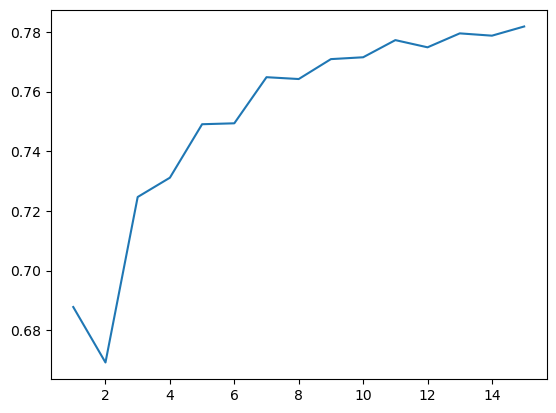

In [4]:
#Graphing different values for K accuracy

scores =[]

for i in range(1,16):
    knn =KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_sca_train,y_train.values.ravel())

    y_pred = knn.predict(X_sca_test)
    scores.append(accuracy_score(y_test.values.ravel(),y_pred.ravel()))

plt.plot(range(1,16),scores)

In [ ]:
plt.scatter(df[:, 0], df[:, 1], c=y_pred, s=50, cmap='viridis')

# 4. Plot the centroids (cluster centers)
centers = knn.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')

plt.title("K-Means Clustering")
plt.legend()
plt.show()